In [26]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

In [2]:
treino = pd.read_csv('flotacao_treino.csv')
teste = pd.read_csv('flotacao_teste.csv')
target = '4_RJT2VI_QQ_GLOBAL_Fe' 
time_stamp = 'timestamp'
treino[time_stamp] = pd.to_datetime(treino[time_stamp])
y_treino = treino[target]

In [12]:
decomposicao = seasonal_decompose(y_treino.reset_index(drop=True), model='additive', period=24)

# 2. Criando a figura com 4 subplots compartilhando o eixo X
fig = make_subplots(
    rows=4, cols=1, 
    shared_xaxes=True,
    vertical_spacing=0.05,
    subplot_titles=('Série Observada (Teor de Fe)', 'Tendência', 'Sazonalidade', 'Resíduos')
)

# Definindo o eixo X (índices)
x_val = y_treino.reset_index(drop=True).index

# 3. Adicionando as linhas (Traces) para cada componente
# Observado
fig.add_trace(go.Scatter(x=x_val, y=decomposicao.observed, mode='lines', name='Observado', line=dict(color='#1f77b4')), row=1, col=1)

# Tendência
fig.add_trace(go.Scatter(x=x_val, y=decomposicao.trend, mode='lines', name='Tendência', line=dict(color='#ff7f0e')), row=2, col=1)

# Sazonalidade
fig.add_trace(go.Scatter(x=x_val, y=decomposicao.seasonal, mode='lines', name='Sazonalidade', line=dict(color='#2ca02c')), row=3, col=1)

# Resíduos (usando marcadores em vez de linhas, que é o padrão para resíduos)
fig.add_trace(go.Scatter(x=x_val, y=decomposicao.resid, mode='markers', name='Resíduos', marker=dict(color='#d62728', size=5)), row=4, col=1)

# Adicionando uma linha de referência no zero no gráfico de resíduos
fig.add_shape(type='line', x0=x_val.min(), x1=x_val.max(), y0=0, y1=0, line=dict(color='black', dash='dot', width=1), row=4, col=1)

# 4. Ajustando o layout
fig.update_layout(
    height=800, 
    title_text="Decomposição Interativa da Série Temporal (Plotly)",
    showlegend=False,
    hovermode="x unified" # Mostra os valores de todos os gráficos ao passar o mouse
)

fig.show()

### a) tem tudo

In [6]:
y_treino_log = np.log(y_treino)

In [7]:
fig = make_subplots(
    rows=2, cols=1, 
    shared_xaxes=True,
    vertical_spacing=0.1,
    subplot_titles=('Série Original (Com Heterocedasticidade)', 
                    'Série Transformada (Log - Variância Estabilizada)')
)

# Plotando a série original
fig.add_trace(go.Scatter(
    y=y_treino, 
    mode='lines', 
    name='Original', 
    line=dict(color='#1f77b4')
), row=1, col=1)

# Plotando a série com log
fig.add_trace(go.Scatter(
    y=y_treino_log, 
    mode='lines', 
    name='Log Transformada', 
    line=dict(color='#2ca02c')
), row=2, col=1)

# Ajustando o layout
fig.update_layout(
    height=600, 
    title_text="Efeito da Transformação Logarítmica na Série Temporal",
    showlegend=False,
    hovermode="x unified"
)

fig.show()

In [8]:
y_treino_log_diff = y_treino_log.diff().dropna()

In [17]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    y=y_treino_log_diff,
    mode='lines',
    name='Série Diferenciada',
    line=dict(color='#9467bd')
))

# Adicionando uma linha de referência no zero
fig.add_shape(
    type='line', x0=0, x1=len(y_treino_log_diff), y0=0, y1=0, 
    line=dict(color='black', dash='dot', width=1.5)
)

fig.update_layout(
    title='Série após Transformação Logarítmica e Diferenciação (Estacionária)',
    xaxis_title='Tempo / Índice',
    yaxis_title='Variação do Log(Teor de Fe)',
    height=400,
    hovermode='x unified'
)

fig.show()

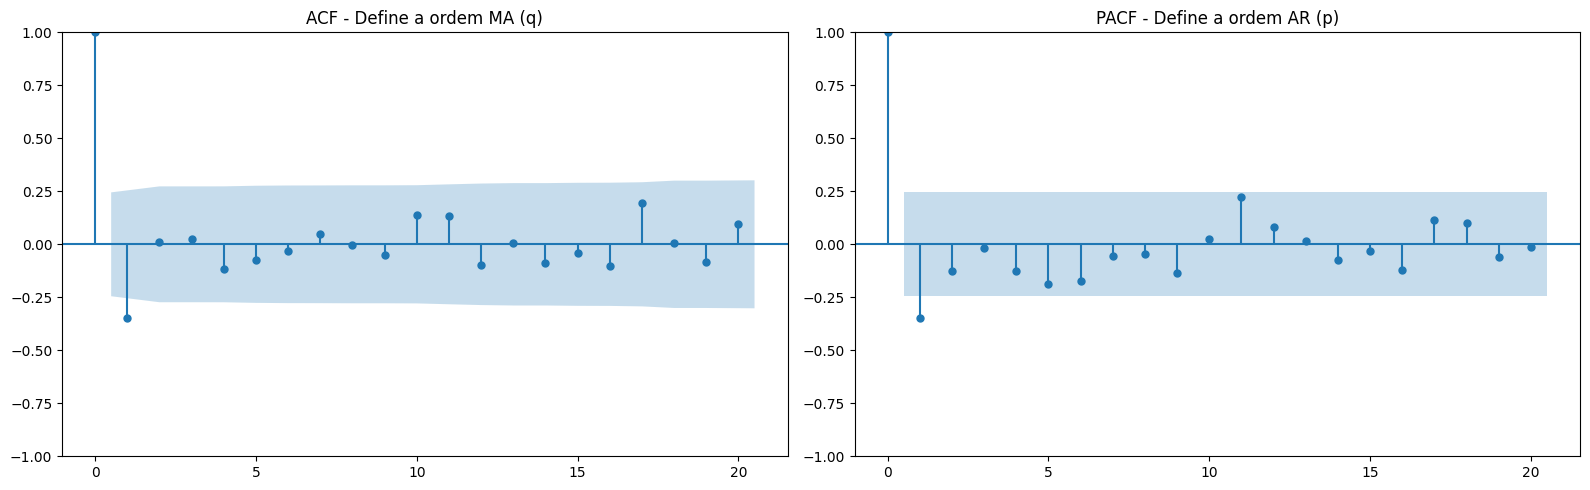

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(y_treino_log_diff, ax=axes[0], lags=20, title='ACF - Define a ordem MA (q)')
plot_pacf(y_treino_log_diff, ax=axes[1], lags=20, title='PACF - Define a ordem AR (p)', method='ywm')

plt.tight_layout()
plt.show()

In [23]:
modelo_ar = ARIMA(y_treino_log_diff, order=(1, 0, 0)).fit()
print("\n=== Coeficientes do Modelo AR(1) ===")
print(modelo_ar.summary().tables[1])

# 2. Modelo MA(1) na série já diferenciada
modelo_ma = ARIMA(y_treino_log_diff, order=(0, 0, 1)).fit()
print("\n=== Coeficientes do Modelo MA(1) ===")
print(modelo_ma.summary().tables[1])

# 3. Modelo ARMA(1, 1) na série já diferenciada
modelo_arma = ARIMA(y_treino_log_diff, order=(1, 0, 1)).fit()
print("\n=== Coeficientes do Modelo ARMA(1, 1) ===")
print(modelo_arma.summary().tables[1])


=== Coeficientes do Modelo AR(1) ===
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0037      0.017     -0.214      0.830      -0.038       0.031
ar.L1         -0.3488      0.084     -4.136      0.000      -0.514      -0.184
sigma2         0.0290      0.003     10.054      0.000       0.023       0.035

=== Coeficientes do Modelo MA(1) ===
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0052      0.013     -0.411      0.681      -0.030       0.019
ma.L1         -0.4643      0.095     -4.897      0.000      -0.650      -0.278
sigma2         0.0281      0.003     10.365      0.000       0.023       0.033

=== Coeficientes do Modelo ARMA(1, 1) ===
                 coef    std err          z      P>|z|      [0.025      0.975]
------------

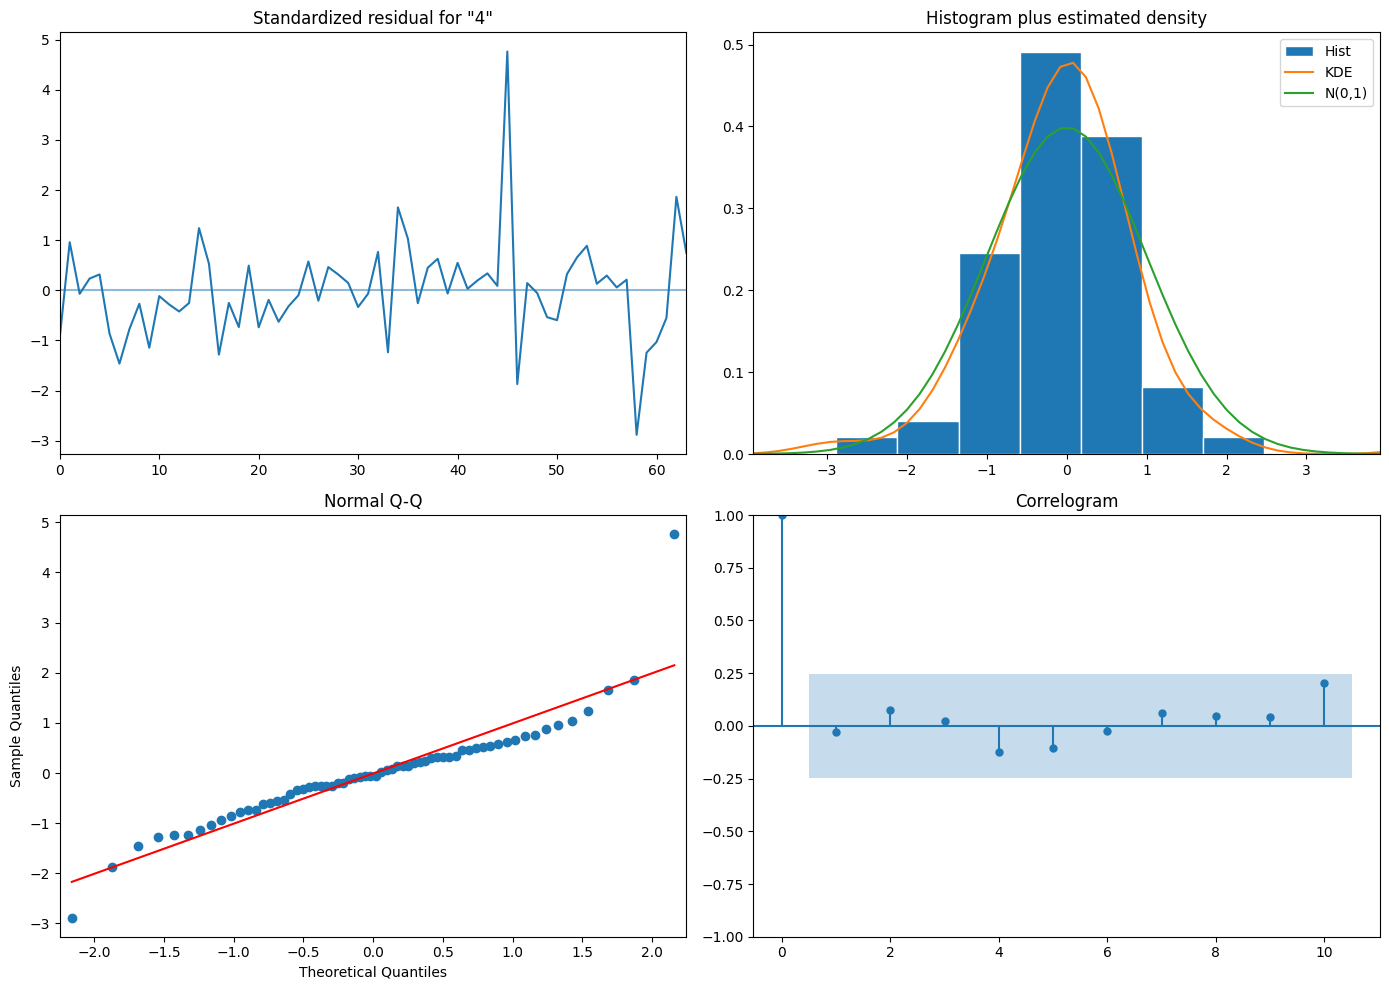

In [25]:
import matplotlib.pyplot as plt

# Gera os gráficos de diagnóstico para o modelo ARIMA(1,1,1) que ajustamos no passo anterior
fig = modelo_arma.plot_diagnostics(figsize=(14, 10))
plt.tight_layout()
plt.show()

### O residuo parece correto, sendo sinal aleatório em torno de 0. A distribuição se aproxima de uma normal. Me parece suficiente

In [27]:
# Isolando a variável alvo no conjunto de teste e aplicando o log (mesmo tratamento do treino)
y_teste = teste['4_RJT2VI_QQ_GLOBAL_Fe'].reset_index(drop=True)
y_teste_log = np.log(y_teste)

print("Iniciando simulação online... Isso pode levar alguns segundos.")

# 1. Preditor Ingênuo (Online)
# A previsão no instante t é o valor real no instante t-1. 
# Para a primeira amostra do teste, a previsão é o último valor real do treino.
pred_ingenua = [y_treino.iloc[-1]] + list(y_teste.iloc[:-1])

# 2. Previsão ARIMA (Online)
historico_log = list(y_treino_log)
previsoes_arima_log = []

# Loop simulando a chegada sequencial dos dados de teste
for i in range(len(y_teste_log)):
    # Ajusta o modelo com o histórico disponível até aquele momento
    modelo_online = ARIMA(historico_log, order=(1, 1, 1)).fit()
    
    # Prevê 1 amostra à frente
    pred_log = modelo_online.forecast()[0]
    previsoes_arima_log.append(pred_log)
    
    # O dado real "chega" e é adicionado ao histórico para a previsão do próximo ciclo
    historico_log.append(y_teste_log.iloc[i])

# Importante: Como previmos em escala logarítmica, precisamos usar a exponencial 
# para voltar os valores à escala original do Teor de Ferro antes de calcular o erro!
previsoes_arima_original = np.exp(previsoes_arima_log)

# 3. Calculando e Comparando o MSE
mse_ingenuo = mean_squared_error(y_teste, pred_ingenua)
mse_arima = mean_squared_error(y_teste, previsoes_arima_original)

print("\n=== Resultado Final (Dados de Teste) ===")
print(f"MSE Preditor Ingênuo: {mse_ingenuo:.4f}")
print(f"MSE Modelo ARIMA:     {mse_arima:.4f}")

Iniciando simulação online... Isso pode levar alguns segundos.


/home/gfalmeida2/repositorios/litc+ihm/env/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals




=== Resultado Final (Dados de Teste) ===
MSE Preditor Ingênuo: 14.1317
MSE Modelo ARIMA:     11.4468


### g) O modelo foi bem comparado com o baseline. 